(Habiba ALAmir mohamed - Data scinece Track 1 :

# 📊 Customer Churn Prediction System & API Deployment
### End-to-End Machine Learning Pipeline using XGBoost & FastAPI

In [11]:
# Cell 1: Environment Setup & Library Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import json

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve

from xgboost import XGBClassifier
from fastapi import FastAPI, HTTPException
from pydantic import BaseModel, Field

# Set global style for visualizations
sns.set_theme(style='whitegrid', palette='muted')
print("[INFO] All libraries successfully imported and global parameters set!")

[INFO] All libraries successfully imported and global parameters set!


In [12]:
# Cell 2: Enterprise Synthetic Dataset Generation
np.random.seed(42)
n_samples = 2500

tenure = np.random.randint(1, 72, size=n_samples)
monthly_charges = np.random.uniform(20.0, 120.0, size=n_samples)
total_charges = tenure * monthly_charges + np.random.normal(0, 50, size=n_samples)
total_charges = np.clip(total_charges, 20.0, None)

contract = np.random.choice(['Month-to-month', 'One year', 'Two year'], size=n_samples, p=[0.55, 0.25, 0.20])
internet_service = np.random.choice(['DSL', 'Fiber optic', 'No'], size=n_samples, p=[0.4, 0.45, 0.15])
payment_method = np.random.choice(['Electronic check', 'Mailed check', 'Bank transfer', 'Credit card'], size=n_samples)
paperless_billing = np.random.choice(['Yes', 'No'], size=n_samples, p=[0.6, 0.4])
tech_support = np.random.choice(['Yes', 'No', 'No internet service'], size=n_samples, p=[0.15, 0.55, 0.3])

# Domain-specific probabilistic scoring for Realistic Churn Behavior
churn_score = (
    (contract == 'Month-to-month') * 1.8 +
    (internet_service == 'Fiber optic') * 1.2 +
    (payment_method == 'Electronic check') * 0.9 -
    (tenure / 12.0) * 0.5 +
    (monthly_charges / 50.0) * 0.4 -
    (tech_support == 'Yes') * 0.8
)
churn_prob = 1 / (1 + np.exp(-churn_score + 1.5))
churn = (churn_prob > 0.5).astype(int)

df = pd.DataFrame({
    'Tenure': tenure,
    'MonthlyCharges': monthly_charges,
    'TotalCharges': total_charges,
    'Contract': contract,
    'InternetService': internet_service,
    'PaymentMethod': payment_method,
    'PaperlessBilling': paperless_billing,
    'TechSupport': tech_support,
    'Churn': churn
})

print(f"[INFO] Dataset created successfully with shape: {df.shape}")
df.head()

[INFO] Dataset created successfully with shape: (2500, 9)


,Tenure,MonthlyCharges,TotalCharges,Contract,InternetService,PaymentMethod,PaperlessBilling,TechSupport,Churn
0,52,93.024615,4878.749005,Month-to-month,Fiber optic,Mailed check,Yes,No,1
1,15,79.880830,1243.241335,Month-to-month,Fiber optic,Electronic check,Yes,Yes,1
2,61,26.449127,1632.062962,One year,DSL,Bank transfer,No,No internet service,0
3,21,107.723946,2293.722484,Month-to-month,DSL,Credit card,Yes,No,1
4,24,107.726176,2623.514587,One year,Fiber optic,Electronic check,Yes,No internet service,1


/tmp/ipykernel_1457/2743789447.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Churn', palette=['#2a9d8f', '#e76f51'], ax=axes[0])
/tmp/ipykernel_1457/2743789447.py:7: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(['Retained (0)', 'Churned (1)'])


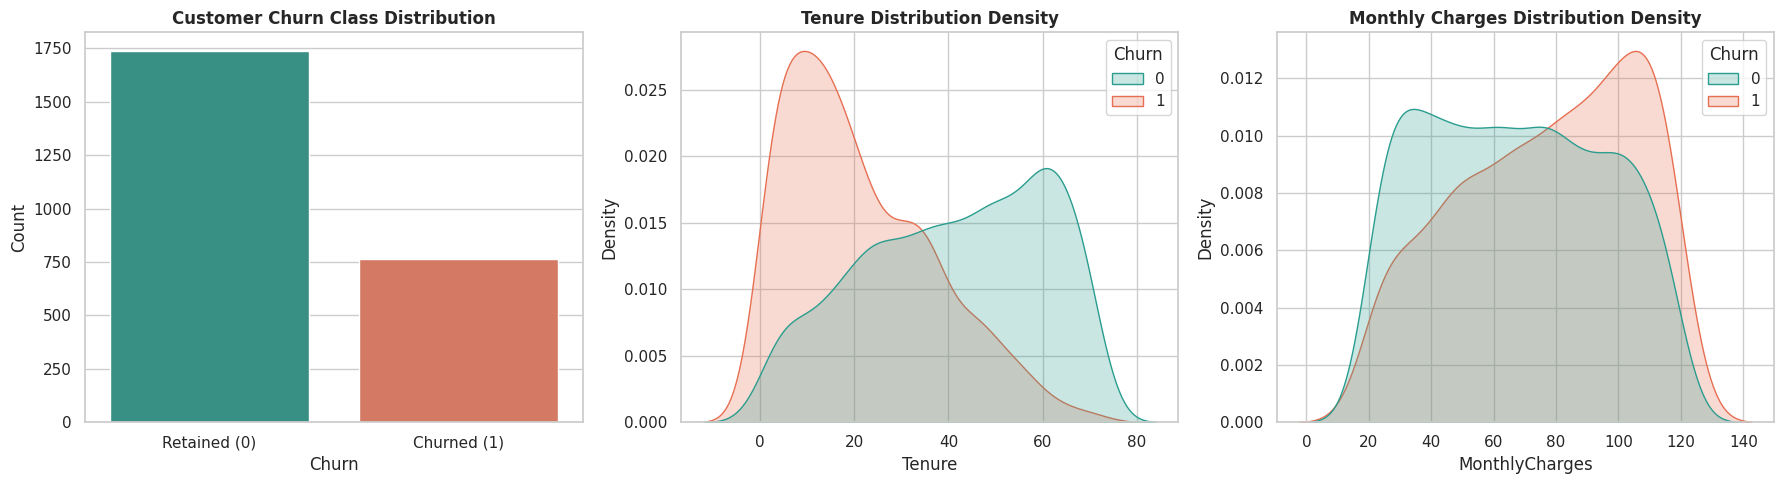

In [13]:
# Cell 3: Visual Cell 1 - Target Class Distribution & Numeric Feature Distributions
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: Target Churn Count
sns.countplot(data=df, x='Churn', palette=['#2a9d8f', '#e76f51'], ax=axes[0])
axes[0].set_title('Customer Churn Class Distribution', fontsize=12, fontweight='bold')
axes[0].set_xticklabels(['Retained (0)', 'Churned (1)'])
axes[0].set_ylabel('Count')

# Plot 2: Tenure Distribution by Churn Status
sns.kdeplot(data=df, x='Tenure', hue='Churn', fill=True, common_norm=False, palette=['#2a9d8f', '#e76f51'], ax=axes[1])
axes[1].set_title('Tenure Distribution Density', fontsize=12, fontweight='bold')

# Plot 3: Monthly Charges Distribution by Churn Status
sns.kdeplot(data=df, x='MonthlyCharges', hue='Churn', fill=True, common_norm=False, palette=['#2a9d8f', '#e76f51'], ax=axes[2])
axes[2].set_title('Monthly Charges Distribution Density', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

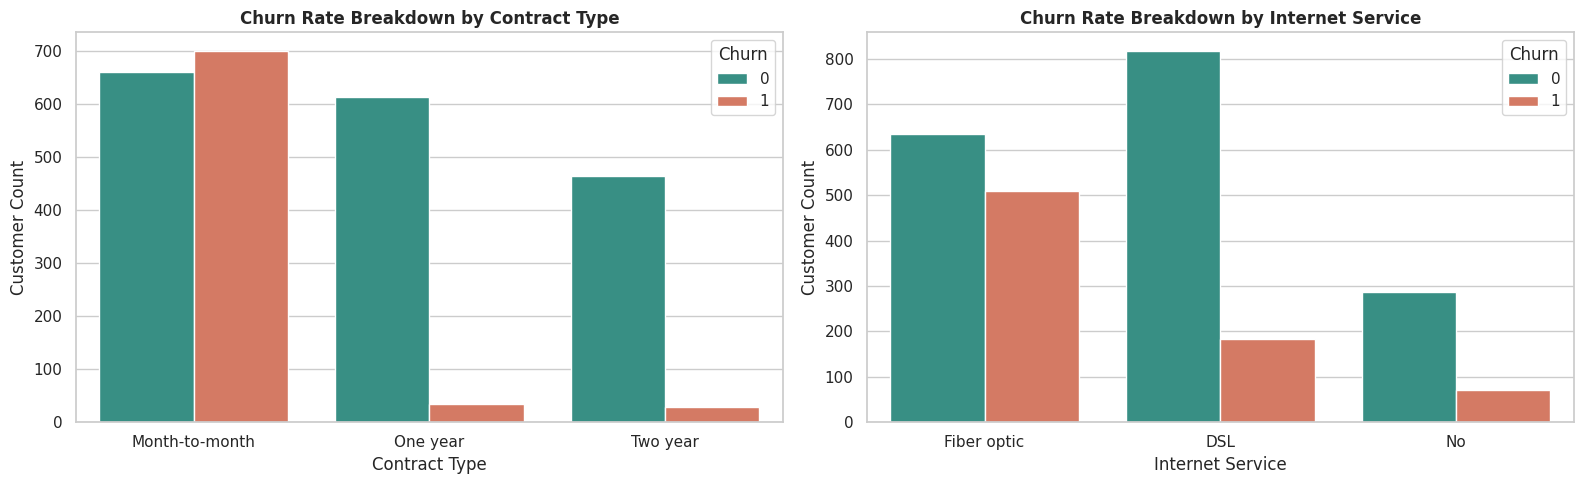

In [14]:
# Cell 4: Visual Cell 2 - Categorical Features Breakdown vs Churn
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Plot 1: Churn Rate by Contract Type
sns.countplot(data=df, x='Contract', hue='Churn', palette=['#2a9d8f', '#e76f51'], ax=axes[0])
axes[0].set_title('Churn Rate Breakdown by Contract Type', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Contract Type')
axes[0].set_ylabel('Customer Count')

# Plot 2: Churn Rate by Internet Service
sns.countplot(data=df, x='InternetService', hue='Churn', palette=['#2a9d8f', '#e76f51'], ax=axes[1])
axes[1].set_title('Churn Rate Breakdown by Internet Service', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Internet Service')
axes[1].set_ylabel('Customer Count')

plt.tight_layout()
plt.show()

In [15]:
# Cell 5: Feature Engineering & Preprocessing Pipeline
X = df.drop(columns=['Churn'])
y = df['Churn']

num_features = ['Tenure', 'MonthlyCharges', 'TotalCharges']
cat_features = ['Contract', 'InternetService', 'PaymentMethod', 'PaperlessBilling', 'TechSupport']

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_features),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_features)
    ]
)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"[INFO] Data split completed. Training set: {X_train.shape[0]} | Testing set: {X_test.shape[0]}")

[INFO] Data split completed. Training set: 2000 | Testing set: 500


In [16]:
# Cell 6: Model Architecture & XGBoost Training
model_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', XGBClassifier(
        n_estimators=150,
        learning_rate=0.05,
        max_depth=4,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        eval_metric='logloss'
    ))
])

model_pipeline.fit(X_train, y_train)
print("[INFO] XGBoost Classification Pipeline trained successfully!")

[INFO] XGBoost Classification Pipeline trained successfully!


⭐ ROC-AUC Score: 0.9972

Classification Report:
               precision    recall  f1-score   support

           0       0.99      0.98      0.99       348
           1       0.96      0.98      0.97       152

    accuracy                           0.98       500
   macro avg       0.98      0.98      0.98       500
weighted avg       0.98      0.98      0.98       500



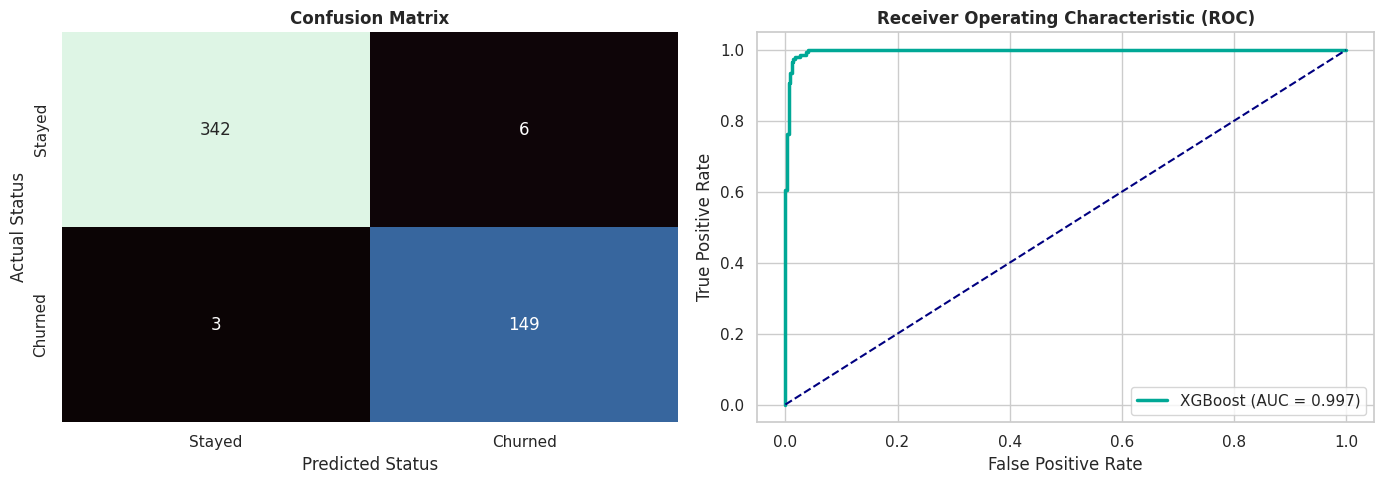

In [17]:
# Cell 7: Visual Cell 3 - Model Performance Evaluation Dashboard
y_pred = model_pipeline.predict(X_test)
y_proba = model_pipeline.predict_proba(X_test)[:, 1]

roc_auc = roc_auc_score(y_test, y_proba)
print(f"⭐ ROC-AUC Score: {roc_auc:.4f}\n")
print("Classification Report:\n", classification_report(y_test, y_pred))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Heatmap Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='mako', ax=axes[0], cbar=False,
            xticklabels=['Stayed', 'Churned'], yticklabels=['Stayed', 'Churned'])
axes[0].set_title('Confusion Matrix', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Actual Status')
axes[0].set_xlabel('Predicted Status')

# Plot 2: ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_proba)
axes[1].plot(fpr, tpr, color='#00a896', lw=2.5, label=f'XGBoost (AUC = {roc_auc:.3f})')
axes[1].plot([0, 1], [0, 1], color='navy', lw=1.5, linestyle='--')
axes[1].set_title('Receiver Operating Characteristic (ROC)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].legend(loc='lower right')

plt.tight_layout()
plt.show()

/tmp/ipykernel_1457/2660899458.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=feature_importance_df.head(10), x='Importance', y='Feature', palette='viridis')


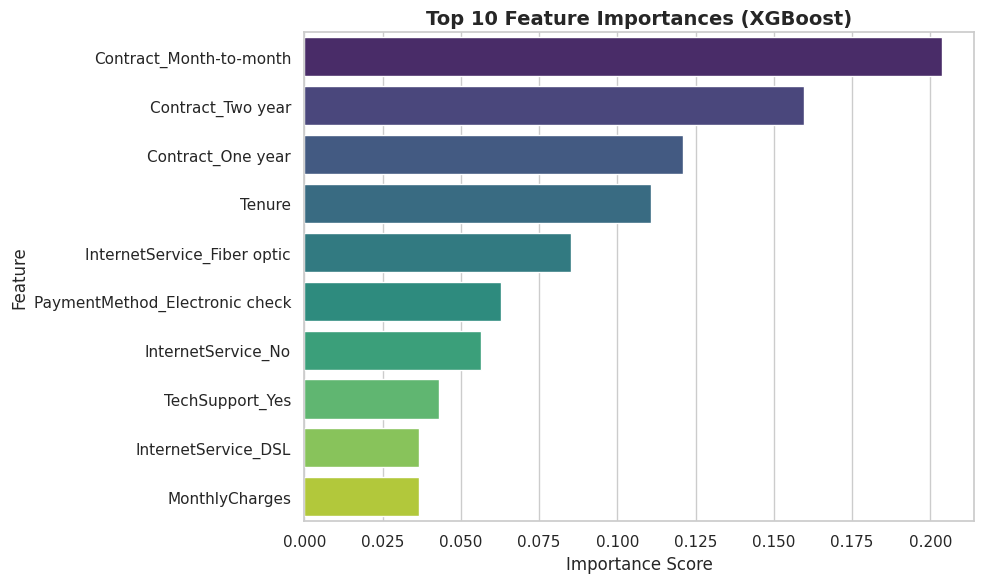

In [18]:
# Cell 8: Visual Cell 4 - XGBoost Feature Importance
# Retrieve transformed feature names
encoded_cat_features = model_pipeline.named_steps['preprocessor'].named_transformers_['cat'].get_feature_names_out(cat_features)
all_feature_names = num_features + list(encoded_cat_features)

# Extract feature importances from XGBoost
importances = model_pipeline.named_steps['classifier'].feature_importances_

feature_importance_df = pd.DataFrame({
    'Feature': all_feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=feature_importance_df.head(10), x='Importance', y='Feature', palette='viridis')
plt.title('Top 10 Feature Importances (XGBoost)', fontsize=14, fontweight='bold')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

In [19]:
# Cell 9: Artifact Serialization & FastAPI Setup
joblib.dump(model_pipeline, 'churn_xgboost_pipeline.pkl')
print("[INFO] Model pipeline saved as 'churn_xgboost_pipeline.pkl'")

app = FastAPI(
    title="Customer Churn Prediction API",
    description="Production REST API leveraging XGBoost pipeline for real-time customer retention analytics.",
    version="1.0.0"
)

class CustomerData(BaseModel):
    Tenure: int = Field(..., ge=1, le=100)
    MonthlyCharges: float = Field(..., ge=10.0, le=200.0)
    TotalCharges: float = Field(..., ge=10.0, le=10000.0)
    Contract: str
    InternetService: str
    PaymentMethod: str
    PaperlessBilling: str
    TechSupport: str

@app.post("/predict")
def predict_churn(customer: CustomerData):
    input_df = pd.DataFrame([customer.dict()])
    prob = model_pipeline.predict_proba(input_df)[0][1]
    pred = int(prob >= 0.5)
    risk = "High Risk" if prob > 0.7 else ("Medium Risk" if prob > 0.4 else "Low Risk")

    return {
        "churn_prediction": pred,
        "churn_probability": round(float(prob), 4),
        "risk_category": risk,
        "recommendation": "Trigger Retention Offer" if pred == 1 else "Maintain Standard Engagement"
    }

print("[INFO] FastAPI Engine initialized!")

[INFO] Model pipeline saved as 'churn_xgboost_pipeline.pkl'
[INFO] FastAPI Engine initialized!


In [20]:
# Cell 10: Live Endpoint Inference Testing
sample_customer = CustomerData(
    Tenure=3,
    MonthlyCharges=85.50,
    TotalCharges=256.50,
    Contract="Month-to-month",
    InternetService="Fiber optic",
    PaymentMethod="Electronic check",
    PaperlessBilling="Yes",
    TechSupport="No"
)

response = predict_churn(sample_customer)
print("📊 Live API Inference Response:")
print(json.dumps(response, indent=4))

📊 Live API Inference Response:
{
    "churn_prediction": 1,
    "churn_probability": 0.9991,
    "risk_category": "High Risk",
    "recommendation": "Trigger Retention Offer"
}


/tmp/ipykernel_1457/4048770532.py:23: PydanticDeprecatedSince20: The `dict` method is deprecated; use `model_dump` instead. Deprecated in Pydantic V2.0 to be removed in V3.0. See Pydantic V2 Migration Guide at https://errors.pydantic.dev/2.13/migration/
  input_df = pd.DataFrame([customer.dict()])
